In [6]:
import sys
from pathlib import Path


BASE_DIR = Path.cwd()

# go UP until we find 'src'
while BASE_DIR != BASE_DIR.parent:
    if (BASE_DIR / "src").exists():
        break
    BASE_DIR = BASE_DIR.parent

sys.path.insert(0, str(BASE_DIR / "src"))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from models.isolation_forest import IsolationForest
from models.dbscan import DBSCAN
from datetime import date,datetime
from dateutil.relativedelta import relativedelta


import warnings

warnings.filterwarnings("ignore")

## Input Parameters

In [7]:
data_type = "intraday"
timeframe = "1min"

stock_name = "CHCL"
features = ["close", "volume", "returns", "volatility"]



z_score_threshold = 3

n_estimators = 200
contamination = 0.01

epsilon = 0.5
min_samples = 5




## Loader

In [8]:
# Data type
if data_type == "intraday":

    all_days = []
    start_date = datetime.strptime("2026-04-09","%Y-%m-%d")
    end_date = datetime.strptime("2026-04-30","%Y-%m-%d")

    for date_folder in sorted(Path("./../../data/intraday").iterdir()):
        if not date_folder.is_dir():
            continue

        date = datetime.strptime(date_folder.name, "%Y-%m-%d")
        if start_date <= date <= end_date:
            file_path = date_folder / f"{stock_name}.csv"

            if file_path.exists():
                df = pd.read_csv(file_path)
                df["transaction_time"] = pd.to_datetime(df["transaction_time"])
                df = df.set_index("transaction_time")
                df = df.sort_index()

                all_days.append(df)

    if not all_days:
        # if no data found returns an empty dataframe
        df = pd.DataFrame()
    else:
        # returns a concatenated dataframe and ignore the index of the dataframe and generate a brand new set of indices
        df = pd.concat(all_days).sort_index()
        df = df.reset_index();
    


  


else:

    start_date = date.today() - relativedelta(years=3)
    end_date = date.today()

    print(start_date)
    print(end_date)

    data_source = stock_name + ".csv"

    df = pd.read_csv(f"{BASE_DIR}/data/interday/{data_source}")
    df.rename(columns={"close": "price"}, inplace=True)


df.head()



,transaction_time,contract_id,symbol,buyer_member_id,seller_member_id,volume,price,amount,buyer_broker,seller_broker
0,2026-04-09 11:10:02.141753,2026040904000721,CHCL,35,77,20,490.0,9800.0,Kohinoor Investment & Securities Pvt. Ltd.,Nabil Stock Dealer Ltd.
1,2026-04-09 11:10:52.354520,2026040904000801,CHCL,70,58,500,485.4,242700.0,Infinity Securities Limited,Naasa Securities Co. Ltd.
2,2026-04-09 11:10:52.354643,2026040904000802,CHCL,40,58,50,485.2,24260.0,Creative Securities Pvt Ltd,Naasa Securities Co. Ltd.
3,2026-04-09 11:11:36.356087,2026040904000912,CHCL,40,26,11,485.2,5337.2,Creative Securities Pvt Ltd,Asian Securities Private Ltd.
4,2026-04-09 11:15:38.307359,2026040904001177,CHCL,57,57,50,485.2,24260.0,Aryatara Investment & Securities,Aryatara Investment & Securities


In [9]:
from plotly.graph_objs import volume

df["Date"] = pd.to_datetime(df["transaction_time"])
df = df.set_index("Date")
df = df.sort_index();

if data_type=='interday':
    df = df.resample(timeframe).agg(
        open = ("open","first"),
        high = ("high","max"),
        low = ("low","min"),
        close = ("close","last"),
        volume = ("volume","sum"),
    )
elif data_type=='intraday':
    df = df.resample(timeframe).agg(
        open = ("price","first"),
        high = ("price","max"),
        low = ("price","min"),
        close = ("price","last"),
        volume = ("volume","sum")
    )




## Data preprocessing

In [10]:
# Data preprocessing
# print(df.columns)

df = df.loc[start_date:end_date].copy()

# drop unnecessary columns
df = df.drop(columns=["transaction_time"],errors="ignore")


# Filter dataframe
df = df.drop_duplicates()

# Compute returns
df["returns"] = df["close"].pct_change()
df["close"] = df["close"].replace(0, np.nan)
df["volatility"] = df["returns"].rolling(window=20).std()


print(df[["close", "volume", "returns", "volatility"]].isna().sum())

df.head()

close          1
volume         0
returns        1
volatility    20
dtype: int64


,open,high,low,close,volume,returns,volatility
Date,,,,,,,
2026-04-09 11:10:00,490.0,490.0,485.2,485.2,570,NaN,NaN
2026-04-09 11:11:00,485.2,485.2,485.2,485.2,11,0.000000,NaN
2026-04-09 11:12:00,NaN,NaN,NaN,NaN,0,0.000000,NaN
2026-04-09 11:15:00,485.2,485.2,485.0,485.0,480,-0.000412,NaN
2026-04-09 11:16:00,485.0,485.0,485.0,485.0,20,0.000000,NaN


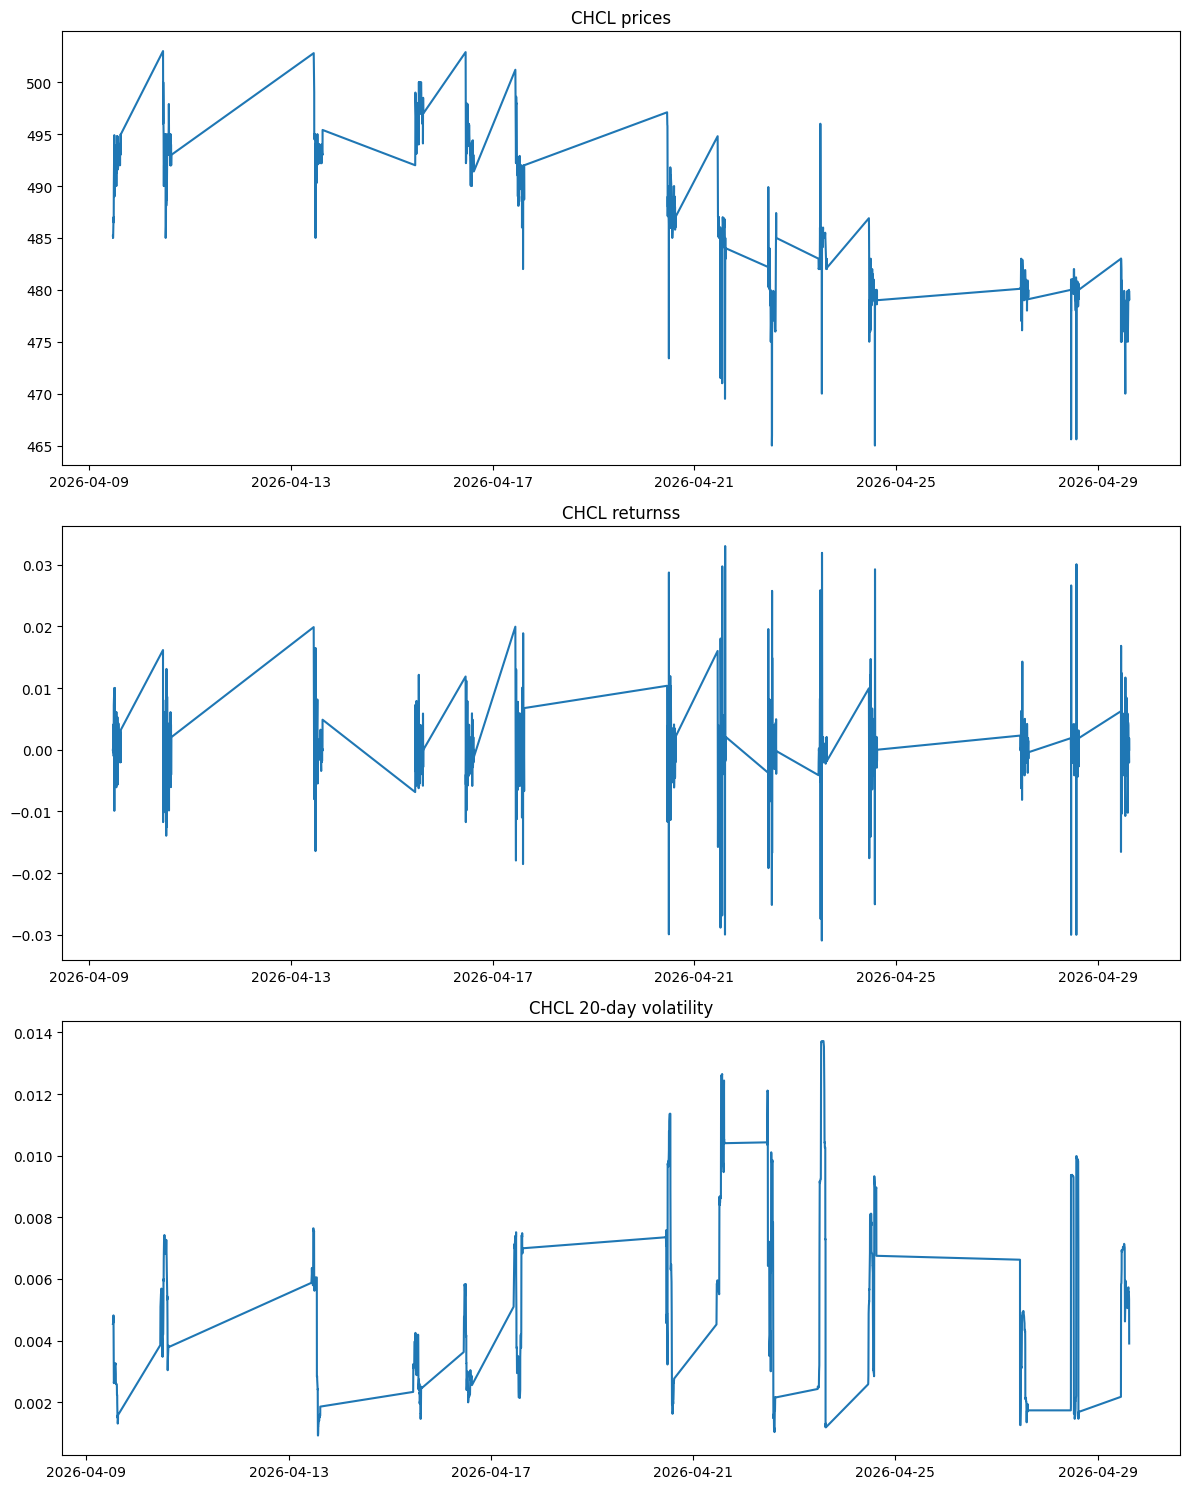

In [11]:
# Plot volatitlity and percent change

fig, axes = plt.subplots(3, 1, figsize=(12, 15))
axes[0].plot(df.index, df["close"])
axes[0].set_title(f"{stock_name} prices")
axes[1].plot(df.index, df["returns"])
axes[1].set_title(f"{stock_name} returnss")
axes[2].plot(df.index, df["volatility"])
axes[2].set_title(f"{stock_name} 20-day volatility")
plt.tight_layout()

plt.show()

In [12]:
# Feature Selection

df[features] = df[features].apply(
    pd.to_numeric, errors="coerce"
)  # converts every value in features columns to numeric value
df.replace(
    [np.inf, -np.inf], np.nan, inplace=True
)  # replace inf and -inf with NaN inplace means in the original dataframe
df = df.dropna(subset=features)  # drops rows where any of the features are NaN

In [13]:
# Feature Enginneering


# 1. Calculate Simple moving averages of last N days

df["SMA_10"] = df["close"].rolling(window=10).mean()
df["SMA_20"] = df["close"].rolling(window=20).mean()
df["SMA_50"] = df["close"].rolling(window=50).mean()


# 2. Calculate Relative Strength Index
def calculate_rsi(data, periods=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=periods).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))


df["RSI"] = calculate_rsi(df["close"])


# Above 70 → asset may be overbought (close went up too fast, may pull back)
# Below 30 → asset may be oversold (close dropped too fast, may bounce back)
# Around 50 → neutral momentum


# 3. Calculate Boilinger bands
df["Upper_BB"] = df["SMA_20"] + (df["close"].rolling(window=20).std() * 2)
df["Lower_BB"] = df["SMA_20"] - (df["close"].rolling(window=20).std() * 2)

df.tail()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB
Date,,,,,,,,,,,,,
2026-04-29 14:51:00,480.0,480.0,480.0,480.0,200,0.000000,0.005517,478.88,477.535,478.440,63.440860,482.570150,472.499850
2026-04-29 14:56:00,480.0,480.0,479.0,479.0,260,-0.002083,0.005347,478.79,477.730,478.452,50.000000,482.669252,472.790748
2026-04-29 14:57:00,479.9,479.9,479.9,479.9,1650,0.001879,0.004662,478.79,478.225,478.480,52.727273,481.656664,474.793336
2026-04-29 14:58:00,479.9,479.9,479.1,479.1,500,-0.001667,0.003960,479.20,478.405,478.462,56.129032,481.604655,475.205345
2026-04-29 14:59:00,479.1,479.1,479.1,479.1,350,0.000000,0.003907,479.40,478.510,478.432,56.493506,481.652845,475.367155


In [14]:
# Plot technical analysis
import plotly.graph_objects as go


# Create the figure
fig = go.Figure()

# Add 'Close' close line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close",
        line=dict(color="blue", width=2),
    )
)

# Add 'SMA 10' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["SMA_10"],
        mode="lines",
        name="SMA 10",
        line=dict(color="green", width=2, dash="dot"),
    )
)

# Add 'SMA 50' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["SMA_50"],
        mode="lines",
        name="SMA 50",
        line=dict(color="orange", width=2, dash="dash"),
    )
)

# Add 'Upper BB' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Upper_BB"],
        mode="lines",
        name="Upper BB",
        line=dict(color="red", width=1, dash="dot"),
    )
)

# Add 'Lower BB' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Lower_BB"],
        mode="lines",
        name="Lower BB",
        line=dict(color="purple", width=1, dash="dot"),
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock close with Technical Indicators",
    xaxis_title="Date",
    yaxis_title="Stock close",
    legend=dict(
        x=0, y=1, bgcolor="rgba(255,255,255,0)", bordercolor="rgba(255,255,255,0)"
    ),
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

# Anomaly Detection Techniques

## Z Score Model


In [15]:
from scipy.stats import zscore
import plotly.graph_objects as go


# Calculate Z Score for close prices
df["Anomaly_Z_Score"] = zscore(df["close"])

# Identify anomalies where Z-Score >3 or < -3
anomalies_zscore = df[abs(df["Anomaly_Z_Score"]) > z_score_threshold]

# Create the figure
fig = go.Figure()

# Add 'Close' close line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close close",
        line=dict(color="blue", width=2),
    )
)

# Add anomalies (Z-score > 3 or < -3) as red markers
fig.add_trace(
    go.Scatter(
        x=anomalies_zscore.index,
        y=anomalies_zscore["close"],
        mode="markers",
        name="Anomalies (Z-Score)",
        marker=dict(color="red", size=8, symbol="circle"),
        showlegend=True,
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock close with Anomalies Detected Using Z-Score",
    xaxis_title="Date",
    yaxis_title="Stock close",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()
# df.sort_values(by="Anomaly_Z_Score",ascending=False).head()
anomalies_zscore.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score
Date,,,,,,,,,,,,,,
2026-04-22 12:53:00,465.0,465.0,465.0,465.0,1,-0.025157,0.006243,476.8,477.715,480.294,22.448980,484.116735,471.313265,-3.02168
2026-04-24 13:56:00,465.0,465.0,465.0,465.0,4,-0.004283,0.006316,477.0,478.310,479.644,10.382514,486.968163,469.651837,-3.02168


## Isolation Forest Approach

Anomalies are easier to isolate than normal points and
because anomalies are rare and far from the cluster, a random split can isolate them quickly.
Normal points are surrounded by many neighbors, so they require more splits

It takes 3 parameters:

**1. n_estimators:** 200 means 200 independent trees are built and then sees how quickly a given point gets isolated across these trees.  
**2. contamination:** 0.01 assumes that 1% of the data is anomalous  
**3. max_depth:** cap a trees height  
**4. random_state:** for reproducibility purposes as without it every run gives slightly different anomalies

Random seed → geneprice random splits  
 ↓  
Build 200 isolation trees  
 ↓  
Compute anomaly scores  
 ↓  
Use contamination (1%) to label anomalies

isolation forest converts the average path length to scores  
short path → high anomaly score  
long path → low anomaly score

max-depth = ceil(log2(max_samples))  
len(X) is how many training rows you have.  
np.log2(n) is “how many times can you halve n before you get down to ~1” — a standard rough size for depth in random/binary tree pictures.  
np.ceil(...) rounds up so you always get an integer depth.  
int(...) makes it a plain Python int for your IsolationForest.

if training data becomes huge we instead find depth by choosing a max-sample size to randomly select samples to cap a tree's height

### Standardization

To standardize means to convert the data to have a mean of 0 and a standard deviation of 1 such that the data is normalized and the model can learn better
#this is important because the model is sensitive to the scale of the data as returns maybe in the range of -0.2 to 0.2 but the other features are in the range of 1000 to 1000000 like quantity


In [16]:
# We can also train the model and fit it in test data, But for simplicity purposes we will fit the model on the entire dataset.

# split_idx = int(len(df) * 0.8) #splits the dataframe into 80% train and 20% test
# df_train = df.iloc[:split_idx].copy() #creates a copy of the train dataframe from the first 80% of the dataframe
# df_test = df.iloc[split_idx:].copy() #creates a copy of the test dataframe from the last 20% of the dataframe


# Only take the selected features
X = df[features]


scaler = StandardScaler()
X = scaler.fit_transform(X)

model_if = IsolationForest(
    n_trees=n_estimators, contamination=contamination, random_state=42
)

df["Anomaly_Isolation_Forest"] = model_if.fit_predict(X)

anomalies_if = df[df["Anomaly_Isolation_Forest"] == -1]


anomalies_if.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score,Anomaly_Isolation_Forest
Date,,,,,,,,,,,,,,,
2026-04-10 12:10:00,492.0,492.0,490.0,490.0,10000,-0.008097,0.003859,492.40,492.400,493.652,50.000000,496.674773,488.125227,0.413964,-1
2026-04-10 12:15:00,491.0,491.0,490.0,490.0,10000,-0.002037,0.003741,491.90,491.500,493.434,45.454545,494.840344,488.159656,0.413964,-1
2026-04-10 12:17:00,490.0,490.0,485.0,485.0,13000,-0.010204,0.004166,490.90,491.250,493.250,37.500000,495.644973,486.855027,-0.273165,-1
2026-04-13 14:59:00,493.0,495.4,493.0,495.4,6600,0.004868,0.001859,493.34,493.220,493.004,72.222222,494.716100,491.723900,1.156063,-1
2026-04-21 14:34:00,469.5,469.5,469.5,469.5,2,-0.029959,0.011643,483.83,483.925,484.274,21.259843,493.499500,474.350500,-2.403264,-1


In [17]:
fig = go.Figure()

# Add Close close line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close close",
        line=dict(color="blue", width=2),
    )
)

# Add anomalies (Isolation Forest) as red markers
fig.add_trace(
    go.Scatter(
        x=anomalies_if.index,
        y=anomalies_if["close"],
        mode="markers",
        name="Anomalies (Isolation Forest)",
        marker=dict(color="red", size=8, symbol="circle"),
        showlegend=True,
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock close with Anomalies Detected Using Isolation Forest",
    xaxis_title="Date",
    yaxis_title="Stock close",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

## DBSCAN

DBSCAN finds anomalies by clustering the data points into density based clusters. It has 2 parameters

**eps: ** It is the radius of the neighborhood around a data point, i.e the max-distance between two samples for them to be considered neighbors
**min_pts: ** The minimum number of data points required within the eps radius to form a dense region.


In [18]:
dbscan = DBSCAN(eps=epsilon, min_pts=min_samples)
df["Anomaly_DBSCAN"] = dbscan.fit_predict(X)

anomalies_dbscan = df.copy()
anomalies_dbscan["Color"] = anomalies_dbscan["Anomaly_DBSCAN"].apply(
    lambda x: "red" if x == -1 else "blue"
)
anomalies_dbscan.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score,Anomaly_Isolation_Forest,Anomaly_DBSCAN,Color
Date,,,,,,,,,,,,,,,,,
2026-04-09 12:33:00,493.4,493.4,493.4,493.4,200,0.000000,0.004542,NaN,NaN,NaN,NaN,NaN,NaN,0.881211,1,1,blue
2026-04-09 12:36:00,493.0,493.0,493.0,493.0,100,-0.000811,0.004554,NaN,NaN,NaN,NaN,NaN,NaN,0.826241,1,1,blue
2026-04-09 12:38:00,492.5,492.5,492.5,492.5,10,-0.001014,0.004569,NaN,NaN,NaN,NaN,NaN,NaN,0.757528,1,1,blue
2026-04-09 12:40:00,492.5,492.5,492.0,492.0,20,-0.001015,0.004579,NaN,NaN,NaN,NaN,NaN,NaN,0.688815,1,1,blue
2026-04-09 12:42:00,491.5,491.5,491.2,491.2,150,-0.001626,0.004607,NaN,NaN,NaN,NaN,NaN,NaN,0.578875,1,1,blue


In [19]:
import plotly.express as px

fig = px.scatter(
    anomalies_dbscan,
    x="close",
    y="volume",
    color="Color",
    title=f"DBSCAN Clustering Results on {stock_name} Data",
    labels={"Color": "Cluster"},
    hover_data=["returns", "volatility"],  # Add more data to hover
)

# Update layout for better visualization
fig.update_layout(
    xaxis_title="Close close",
    yaxis_title="volume",
    legend_title="Cluster",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

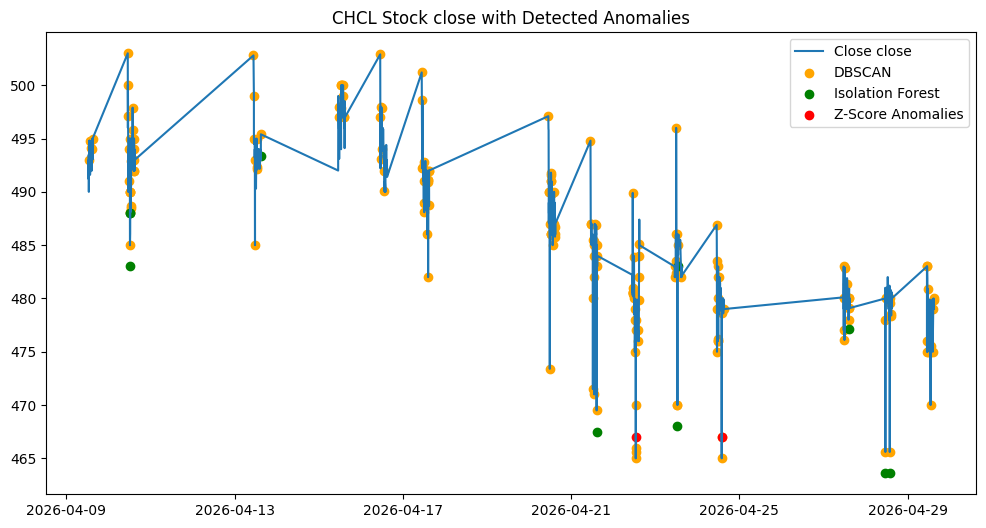

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["close"], label="Close close")


plt.scatter(
    df[df["Anomaly_DBSCAN"] == -1].index,
    df[df["Anomaly_DBSCAN"] == -1]["close"],
    color="orange",
    label="DBSCAN",
)

plt.scatter(
    df[df["Anomaly_Isolation_Forest"] == -1].index,
    df[df["Anomaly_Isolation_Forest"] == -1]["close"] - 2,
    color="green",
    label="Isolation Forest",
)

plt.scatter(
    anomalies_zscore.index,
    anomalies_zscore["close"] + 2,
    color="red",
    label="Z-Score Anomalies",
)

plt.title(f"{stock_name} Stock close with Detected Anomalies")
plt.legend()
plt.show()

In [21]:
import plotly.graph_objects as go


fig = go.Figure()

# Add the line for the closing close
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close close",
        line=dict(color="blue"),
    )
)


# Add the scatter plot for Isolation Forest anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_if[anomalies_if["Anomaly_Isolation_Forest"] == -1].index,
        y=anomalies_if[anomalies_if["Anomaly_Isolation_Forest"] == -1]["close"] - 2,
        mode="markers",
        name="Isolation Forest Anomalies",
        marker=dict(color="green", size=10),
    )
)

# Add the scatter plot for DBSCAN anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_dbscan[anomalies_dbscan["Anomaly_DBSCAN"] == -1].index,
        y=anomalies_dbscan[anomalies_dbscan["Anomaly_DBSCAN"] == -1]["close"],
        mode="markers",
        name="DBSCAN Anomalies",
        marker=dict(color="orange", size=10),
    )
)

# Add the scatter plot for Z-Score anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_zscore.index,
        y=anomalies_zscore["close"] + 2,
        mode="markers",
        name="Z-Score Anomalies",
        marker=dict(color="red", size=10),
    )
)


# Update layout
fig.update_layout(
    title=f"{stock_name} Stock close with Detected Anomalies",
    xaxis_title="Date",
    yaxis_title="Close close",
    legend_title="Legend",
    width=1200,
    height=600,
)

# Show the plot
fig.show()

In [22]:
print("Number of Z-Score Anomalies:", len(anomalies_zscore))
print("Number of Isolation Forest Anomalies:", len(anomalies_if == -1))
print("Number of DBSCAN Anomalies:", sum(anomalies_dbscan["Anomaly_DBSCAN"] == -1))

Number of Z-Score Anomalies: 2
Number of Isolation Forest Anomalies: 10
Number of DBSCAN Anomalies: 208



Confusion Matrix for Z_Score:
[[935   2]
 [  0   0]]


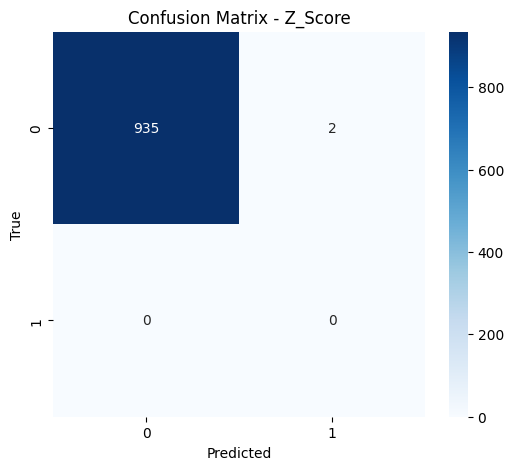


Confusion Matrix for Isolation_Forest:
[[927  10]
 [  0   0]]


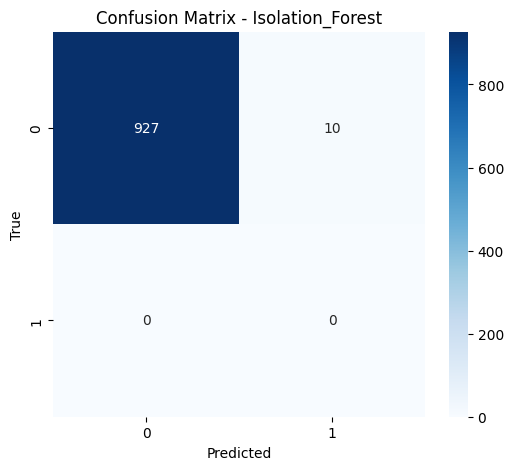


Confusion Matrix for DBSCAN:
[[729 208]
 [  0   0]]


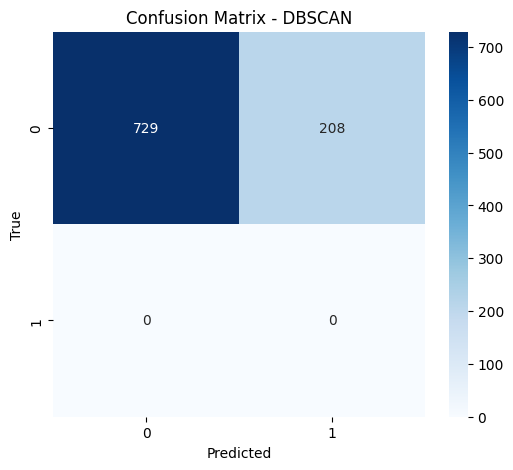


Comparison of all methods:
             Method  Precision  Recall  F1-Score
0           Z_Score        0.0     0.0       0.0
1  Isolation_Forest        0.0     0.0       0.0
2            DBSCAN        0.0     0.0       0.0


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

df["True_Anomaly"] = df["close"].pct_change().abs() > 0.05

methods = ["Z_Score", "Isolation_Forest", "DBSCAN"]
results = []

for method in methods:
    if method == "Z_Score":
        predictions = (abs(df["Anomaly_Z_Score"]) > 3).astype(int)
    elif method == "Isolation_Forest":
        predictions = (df["Anomaly_Isolation_Forest"] == -1).astype(int)
    elif method == "DBSCAN":
        predictions = (df["Anomaly_DBSCAN"] == -1).astype(int)

    precision = precision_score(df["True_Anomaly"], predictions)
    recall = recall_score(df["True_Anomaly"], predictions)
    f1 = f1_score(df["True_Anomaly"], predictions)

    cm = confusion_matrix(df["True_Anomaly"], predictions)

    print(f"\nConfusion Matrix for {method}:")
    print(cm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion Matrix - {method}")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

    results.append(
        {"Method": method, "Precision": precision, "Recall": recall, "F1-Score": f1}
    )

results_df = pd.DataFrame(results)
print("\nComparison of all methods:")
print(results_df)